In [13]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import plotly.graph_objects as go

In [33]:
############ customization
## The OG setting
length = 24
width = 24
n1 = 9
n2 = 2
n = 6 
judge = 0
height = 6
Mid_height = 12 
Side_height = 6.12

# length = 24
# width = 24
# n1 = 6
# n2 = 2
# n = 5 
# judge = 0
# height = 6
# Mid_height = 3
# Side_height = 6

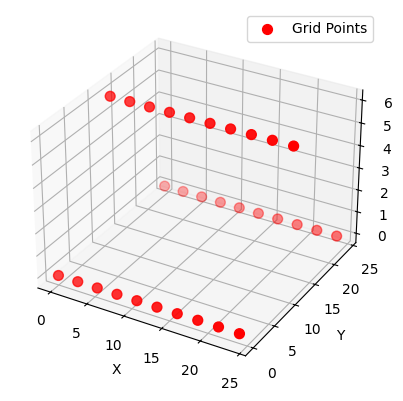

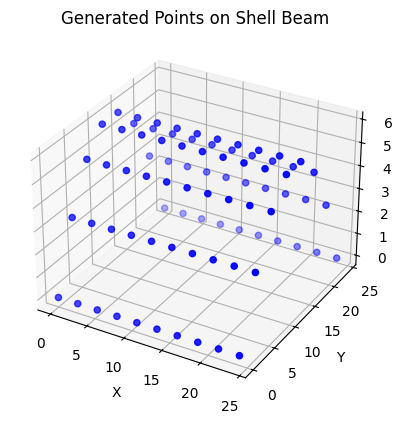

In [34]:
######### THis is for single curvatures
import torch
import numpy as np
import matplotlib.pyplot as plt

def generate_rectangular_grid_sg(length, width, n1, n2=2, judge=0, z=0, height=height):
    x_points = [i * (length / n1) for i in range(n1 + 1)]
    y_points = [j * (width / n2) for j in range(n2, -1, -1)]

    grid_points = []
    for y in y_points:
        for x in x_points:
            if y == width / 2:
                grid_points.append([x, y, height])
            else:
                grid_points.append([x, y, z])

    if judge == 1:
        corners = [
            [x_points[0], y_points[0], z],
            [x_points[0], y_points[-1], z],
            [x_points[-1], y_points[0], z],
            [x_points[-1], y_points[-1], z]
        ]
        grid_points = [point for point in grid_points if point not in corners]

    return grid_points

def add_points(node_coords_sg, n):
    node_coords = node_coords_sg.numpy()
    x_values = np.unique(node_coords[:, 0])
    new_coords = []

    for x in x_values:
        points_on_line = node_coords[node_coords[:, 0] == x]
        y_values = points_on_line[:, 1]
        z_values = points_on_line[:, 2]
        coefficients = np.polyfit(y_values, z_values, 2)
        a, b, c = coefficients
        y_new = np.linspace(max(y_values), min(y_values), n + 2)
        z_new = a * y_new**2 + b * y_new + c

        for y, z in zip(y_new, z_new):
            new_coords.append([x, y, z])

    new_coords = torch.tensor(new_coords, dtype=torch.float32)
    return new_coords

def generate_connectivity_matrix(new_coords):

    indexed_points = {tuple(point): idx + 1 for idx, point in enumerate(new_coords)}

    connectivity = []


    x_values = sorted(set(point[0] for point in new_coords))
    for x in x_values:

        points_on_line = [point for point in new_coords if point[0] == x]
        points_on_line.sort(key=lambda p: p[1], reverse=True) 


        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])


    y_values = sorted(set(point[1] for point in new_coords))
    for y in y_values:
       
        points_on_line = [point for point in new_coords if point[1] == y]
        points_on_line.sort(key=lambda p: p[0])  


        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])

    return connectivity

grid_points_sg = generate_rectangular_grid_sg(length, width, n1, n2, judge)

node_coords_sg = torch.tensor(grid_points_sg)

new_coords_sg = add_points(node_coords_sg, n)

new_coords_sg = new_coords_sg.tolist()

connectivity_sg = generate_connectivity_matrix(new_coords_sg)

new_coords_sg = torch.tensor(new_coords_sg, dtype=torch.float32)
############## plotting

def plot_grid(grid_points, length, width):
    x = [point[0] for point in grid_points]
    y = [point[1] for point in grid_points]
    z = [point[2] for point in grid_points]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, c='r', marker='o', s=50, label='Grid Points')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.show()


def plot_points(points):
    if isinstance(points, list):
        points = torch.tensor(points, dtype=torch.float32)
    points = points.numpy()
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]
    ax.scatter(x, y, z, c='b', marker='o')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Generated Points on Shell Beam')
    plt.show()


plot_grid(grid_points_sg,length,width)
plot_points(new_coords_sg)



# for point in grid_points_sg:
#     print(point)
# print("新的坐标点集：")
# print(new_coords_sg)
# print("连接矩阵：")
# print(connectivity_sg)

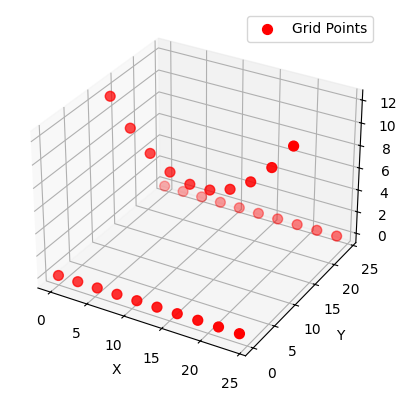

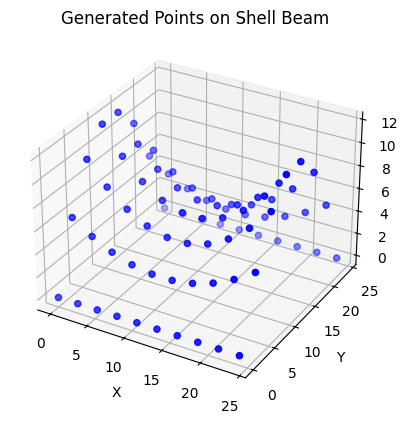

tensor([[ 0.0000e+00,  2.4000e+01,  2.8422e-14],
        [ 0.0000e+00,  2.0571e+01,  5.8776e+00],
        [ 0.0000e+00,  1.7143e+01,  9.7959e+00],
        [ 0.0000e+00,  1.3714e+01,  1.1755e+01],
        [ 0.0000e+00,  1.0286e+01,  1.1755e+01],
        [ 0.0000e+00,  6.8571e+00,  9.7959e+00],
        [ 0.0000e+00,  3.4286e+00,  5.8776e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 2.6667e+00,  2.4000e+01,  1.7214e-14],
        [ 2.6667e+00,  2.0571e+01,  4.7398e+00],
        [ 2.6667e+00,  1.7143e+01,  7.8996e+00],
        [ 2.6667e+00,  1.3714e+01,  9.4795e+00],
        [ 2.6667e+00,  1.0286e+01,  9.4795e+00],
        [ 2.6667e+00,  6.8571e+00,  7.8996e+00],
        [ 2.6667e+00,  3.4286e+00,  4.7398e+00],
        [ 2.6667e+00,  0.0000e+00, -4.1023e-15],
        [ 5.3333e+00,  2.4000e+01,  1.0109e-14],
        [ 5.3333e+00,  2.0571e+01,  3.8864e+00],
        [ 5.3333e+00,  1.7143e+01,  6.4774e+00],
        [ 5.3333e+00,  1.3714e+01,  7.7729e+00],
        [ 5.3333e+00

In [35]:
######### THis is for double curvatures
import torch
import numpy as np
import matplotlib.pyplot as plt

def generate_rectangular_grid_db(length, width, n1, n2=2, judge=0, z=0, Max_height=Mid_height, Min_height=Side_height):
    x_ori = [i * (length / n1) for i in range(n1 + 1)]
    y_points = [j * (width / n2) for j in range(n2, -1, -1)]
    
    x_values = [0, width/2, width]
    z_values = [Max_height, Min_height ,Max_height]
    
    coefficients = np.polyfit(x_values, z_values, 2)
    a, b, c = coefficients
    x_points = np.linspace(min(x_ori), max(x_ori), n1 + 1)
    height = a * x_points**2 + b * x_points + c

    grid_points = []
    for y in y_points:
        for idx, x in enumerate(x_points):
            if y == width / 2:
                grid_points.append([x, y, height[idx]])
            else:
                grid_points.append([x, y, z])

    if judge == 1:
        corners = [
            [x_points[0], y_points[0], z],
            [x_points[0], y_points[-1], z],
            [x_points[-1], y_points[0], z],
            [x_points[-1], y_points[-1], z]
        ]
        grid_points = [point for point in grid_points if point not in corners]

    return grid_points

def add_points(node_coords_sg, n):
    node_coords = node_coords_sg.numpy()
    x_values = np.unique(node_coords[:, 0])
    new_coords = []

    for x in x_values:
        points_on_line = node_coords[node_coords[:, 0] == x]
        y_values = points_on_line[:, 1]
        z_values = points_on_line[:, 2]
        coefficients = np.polyfit(y_values, z_values, 2)
        a, b, c = coefficients
        y_new = np.linspace(max(y_values), min(y_values), n + 2)
        z_new = a * y_new**2 + b * y_new + c

        for y, z in zip(y_new, z_new):
            new_coords.append([x, y, z])

    new_coords = torch.tensor(new_coords, dtype=torch.float32)
    return new_coords

def generate_connectivity_matrix(new_coords):

    indexed_points = {tuple(point): idx + 1 for idx, point in enumerate(new_coords)}

    connectivity = []


    x_values = sorted(set(point[0] for point in new_coords))
    for x in x_values:

        points_on_line = [point for point in new_coords if point[0] == x]
        points_on_line.sort(key=lambda p: p[1], reverse=True) 


        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])


    y_values = sorted(set(point[1] for point in new_coords))
    for y in y_values:
       
        points_on_line = [point for point in new_coords if point[1] == y]
        points_on_line.sort(key=lambda p: p[0])  


        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])

    return connectivity

grid_points_db = generate_rectangular_grid_db(length, width, n1, n2, judge)

node_coords_db = torch.tensor(grid_points_db)

new_coords_db = add_points(node_coords_db, n)

new_coords_db = new_coords_db.tolist()

connectivity_db = generate_connectivity_matrix(new_coords_db)

new_coords_db = torch.tensor(new_coords_db, dtype=torch.float32)

############## plotting

def plot_grid(grid_points, length, width):
    x = [point[0] for point in grid_points]
    y = [point[1] for point in grid_points]
    z = [point[2] for point in grid_points]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, c='r', marker='o', s=50, label='Grid Points')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.show()


def plot_points(points):
    if isinstance(points, list):
        points = torch.tensor(points, dtype=torch.float32)
    points = points.numpy()
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]
    ax.scatter(x, y, z, c='b', marker='o')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Generated Points on Shell Beam')
    plt.show()


plot_grid(grid_points_db,length,width)
plot_points(new_coords_db)



# for point in grid_points_db:
#     print(point)
# print("新的坐标点集：")
print(new_coords_db)
# print("连接矩阵：")
# print(connectivity_db)

In [36]:
################################### FE
D_radius = 0.75
D_young_modulus = 10e9 
D_shear_modulus = 0.7e9 
D_poisson_ratio = 0.3
cross_section_angle_a = 0  
cross_section_angle_b = 0  
a_small_number = 1e-10


def rotation(v, k, theta):
    """Rotation of vector v around axis k by angle theta."""
    k = k / torch.norm(k)  # Normalize k
    cross_product = torch.cross(k, v)
    dot_product = torch.dot(k, v)

    # Ensure theta is a tensor
    theta = torch.tensor(theta, dtype=torch.float32) if not isinstance(theta, torch.Tensor) else theta

    v_rotated = v * torch.cos(theta) + cross_product * torch.sin(theta) + k * dot_product * (1 - torch.cos(theta))
    return v_rotated


# For circular sections
class Beam:
    def __init__(self, node_coordinates, R=D_radius, young_modulus=D_young_modulus,
                 shear_modulus=D_shear_modulus, poisson_ratio=D_poisson_ratio, Beta_a=cross_section_angle_a,
                 Beta_b=cross_section_angle_b):
        self.node_coordinates = node_coordinates  # (2, 3) tensor for node coordinates

        # Material and geometry
        self.radius = R
        self.young_modulus = young_modulus
        self.shear_modulus = shear_modulus
        self.poisson_ratio = poisson_ratio

        # Cross-sectional properties
        self.length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])  # Length of the beam
        self.Iy = (torch.pi * self.radius ** 4) / 4 
        self.Iz = self.Iy
        self.A = torch.pi * self.radius ** 2
        self.J = (torch.pi * self.radius ** 4) / 2

        # Stiffness components
        self.S_u = self.young_modulus * self.A / self.length
        self.S_v1a = 12 * self.young_modulus * self.Iy / (self.length ** 3)
        self.S_v1b = 6 * self.young_modulus * self.Iy / (self.length ** 2)
        self.S_v2a = 12 * self.young_modulus * self.Iz / (self.length ** 3)
        self.S_v2b = 6 * self.young_modulus * self.Iz / (self.length ** 2)
        self.S_theta1a = 6 * self.young_modulus * self.Iy / (self.length ** 2)
        self.S_theta1b = 4 * self.young_modulus * self.Iy / self.length
        self.S_theta1c = 2 * self.young_modulus * self.Iy / self.length
        self.S_theta2a = 6 * self.young_modulus * self.Iz / (self.length ** 2)
        self.S_theta2b = 4 * self.young_modulus * self.Iz / self.length
        self.S_theta2c = 2 * self.young_modulus * self.Iz / self.length
        self.S_Tr = self.shear_modulus * self.J / self.length

        # Section rotations at the two ends
        self.Beta_a = Beta_a
        self.Beta_b = Beta_b

    def get_element_stiffness_matrix(self):
        """Element stiffness matrix."""
        K_element = torch.tensor([
            [self.S_u, 0, 0, 0, 0, 0, -self.S_u, 0, 0, 0, 0, 0],
            [0, self.S_v1a, 0, 0, 0, self.S_theta1a, 0, -self.S_v1a, 0, 0, 0, self.S_theta1a],
            [0, 0, self.S_v2a, 0, -self.S_theta2a, 0, 0, 0, -self.S_v2a, 0, -self.S_theta2a, 0],
            [0, 0, 0, self.S_Tr, 0, 0, 0, 0, 0, -self.S_Tr, 0, 0],
            [0, 0, -self.S_v2b, 0, self.S_theta2b, 0, 0, 0, self.S_v2b, 0, self.S_theta2c, 0],
            [0, self.S_v1b, 0, 0, 0, self.S_theta1b, 0, -self.S_v1b, 0, 0, 0, self.S_theta1c],
            [-self.S_u, 0, 0, 0, 0, 0, self.S_u, 0, 0, 0, 0, 0],
            [0, -self.S_v1a, 0, 0, 0, -self.S_theta1a, 0, self.S_v1a, 0, 0, 0, -self.S_theta1a],
            [0, 0, -self.S_v2a, 0, self.S_theta2a, 0, 0, 0, self.S_v2a, 0, self.S_theta2a, 0],
            [0, 0, 0, -self.S_Tr, 0, 0, 0, 0, 0, self.S_Tr, 0, 0],
            [0, 0, -self.S_v2b, 0, self.S_theta2c, 0, 0, 0, self.S_v2b, 0, self.S_theta2b, 0],
            [0, self.S_v1b, 0, 0, 0, self.S_theta1c, 0, -self.S_v1b, 0, 0, 0, self.S_theta1b],
        ], dtype=torch.float32)

        return K_element

    def System_Transform(self):
        """Coordinate transformation matrix."""
        vector_x = self.node_coordinates[1, 0] - self.node_coordinates[0, 0]
        vector_y = self.node_coordinates[1, 1] - self.node_coordinates[0, 1]
        vector_z = self.node_coordinates[1, 2] - self.node_coordinates[0, 2]
        length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])
        # print(vector_x,vector_y,vector_z)
        # Calculate alpha and ceta using PyTorch
        z_value = torch.clamp(vector_z / length, min=-1 + 1e-6, max=1 - 1e-6)
        ceta = torch.acos(z_value)
        value = vector_x / torch.sqrt(vector_y ** 2 + vector_x ** 2 + a_small_number)
        value = torch.clamp(value, min=-1 + 1e-6, max=1 - 1e-6)
        alpha = torch.acos(value)
        # print(alpha)

        Projection_Z_x = - vector_z / length * torch.sin(alpha)
        Projection_Z_y = - vector_z / length * torch.cos(alpha)
        Projection_Z_z = torch.cos(torch.pi / 2 - ceta)

        V_projection = torch.stack([Projection_Z_x, Projection_Z_y, Projection_Z_z])
        X_axis = torch.stack([vector_x / length, vector_y / length, vector_z / length])
        Z_axis_a = rotation(V_projection, X_axis, self.Beta_a)

        # Z_axis_b = rotation(V_projection, X_axis, self.Beta_b)
        Y_axis_a = rotation(Z_axis_a, X_axis, -torch.pi / 2)
        # Y_axis_b = rotation(Z_axis_b, X_axis, torch.pi / 2)
        Z_axis_a = Z_axis_a / torch.norm(Z_axis_a)
        # Z_axis_b = Z_axis_b / torch.norm(Z_axis_b)
        Y_axis_a = Y_axis_a / torch.norm(Y_axis_a)
        # Y_axis_b = Y_axis_b / torch.norm(Y_axis_b)

        lambda_matrix = torch.stack([X_axis, Y_axis_a, Z_axis_a], dim=0)
        matrix_T = torch.zeros((12, 12), dtype=torch.float32)
        for i in range(0, 12, 3):
            matrix_T[i:i + 3, i:i + 3] = lambda_matrix
        return matrix_T

    def nodal_transform(self):
        """Coordinate transformation matrix."""
        vector_x = self.node_coordinates[1, 0] - self.node_coordinates[0, 0]
        vector_y = self.node_coordinates[1, 1] - self.node_coordinates[0, 1]
        vector_z = self.node_coordinates[1, 2] - self.node_coordinates[0, 2]
        length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])
        # Calculate alpha and ceta using PyTorch
        z_value = torch.clamp(vector_z / length, min=-1 + 1e-6, max=1 - 1e-6)
        ceta = torch.acos(z_value)
        value = vector_x / torch.sqrt(vector_y ** 2 + vector_x ** 2 + a_small_number)
        value = torch.clamp(value, min=-1 + 1e-6, max=1 - 1e-6)
        alpha = torch.acos(value)

        Projection_Z_x = - vector_z / length * torch.sin(alpha)
        Projection_Z_y = - vector_z / length * torch.cos(alpha)
        Projection_Z_z = torch.cos(torch.pi / 2 - ceta)

        V_projection = torch.stack([Projection_Z_x, Projection_Z_y, Projection_Z_z])
        X_axis = torch.stack([vector_x / length, vector_y / length, vector_z / length])
        Z_axis_a = rotation(V_projection, X_axis, self.Beta_a)

        # Z_axis_b = rotation(V_projection, X_axis, self.Beta_b)
        Y_axis_a = rotation(Z_axis_a, X_axis, -torch.pi / 2)
        # Y_axis_b = rotation(Z_axis_b, X_axis, torch.pi / 2)
        Z_axis_a = Z_axis_a / torch.norm(Z_axis_a)
        # Z_axis_b = Z_axis_b / torch.norm(Z_axis_b)
        Y_axis_a = Y_axis_a / torch.norm(Y_axis_a)
        # Y_axis_b = Y_axis_b / torch.norm(Y_axis_b)

        lambda_matrix = torch.stack([X_axis, Y_axis_a, Z_axis_a], dim=0)

        return lambda_matrix


# In[676]:


def assemble_stiffness_matrix(beams, n_nodes, n_dof_per_node, connectivity):
    """Global stiffness matrix assembly."""
    total_dof = n_nodes * n_dof_per_node  # Total degrees of freedom
    K_global = torch.zeros((total_dof, total_dof), dtype=torch.float32)
    for idx, (i, j) in enumerate(connectivity):
        Matrix_T = beams[idx].System_Transform()  # Get transformation matrix

        K_element = torch.matmul(torch.transpose(Matrix_T, 0, 1),
                                 torch.matmul(beams[idx].get_element_stiffness_matrix(), Matrix_T))

        start_idx = (i - 1) * n_dof_per_node
        end_idx = (j - 1) * n_dof_per_node
        K_global[start_idx:start_idx + 6, start_idx:start_idx + 6] = K_global[start_idx:start_idx + 6,
                                                                     start_idx:start_idx + 6] + K_element[0:6, 0:6]
        K_global[end_idx:end_idx + 6, end_idx:end_idx + 6] = K_global[end_idx:end_idx + 6,
                                                             end_idx:end_idx + 6] + K_element[6:12, 6:12]
        K_global[start_idx:start_idx + 6, end_idx:end_idx + 6] = K_global[start_idx:start_idx + 6,
                                                                 end_idx:end_idx + 6] + K_element[0:6, 6:12]
        K_global[end_idx:end_idx + 6, start_idx:start_idx + 6] = K_global[end_idx:end_idx + 6,
                                                                 start_idx:start_idx + 6] + K_element[6:12, 0:6]

    return K_global


def Strain_E(node_coords, connectivity, fixed_dof, F):
    # node_coords[:, 2] = 0.0
    # Element Assembly
    Beam_lens = []
    beams = []
    for connection in connectivity:
        node_1_coords = node_coords[connection[0] - 1]
        node_2_coords = node_coords[connection[1] - 1]
        beam = Beam(node_coordinates=torch.stack([node_1_coords, node_2_coords]),
                    R=D_radius, young_modulus=D_young_modulus,
                    shear_modulus=D_shear_modulus, poisson_ratio=D_poisson_ratio, Beta_a=cross_section_angle_a,
                    Beta_b=cross_section_angle_b)
        beams.append(beam)
        Beam_lens.append(beam.length)
    # Stiffness renewal
    K_global = assemble_stiffness_matrix(beams, n_nodes=len(node_coords), n_dof_per_node=6, connectivity=connectivity)
    K_global[fixed_dof, :] = K_global[fixed_dof, :] - K_global[fixed_dof, :]
    K_global[:, fixed_dof] = K_global[:, fixed_dof] - K_global[:, fixed_dof]
    K_global[fixed_dof, fixed_dof] = 1e8
    rank_K = torch.linalg.matrix_rank(K_global)

    if rank_K < K_global.shape[0]:
        print("Warning: The stiffness matrix is not of full rank")
    else:
        displacements = torch.linalg.solve(K_global, F)

    # Compute strain energy
    strain_energy_list = []
    Local_d = torch.zeros(len(connectivity), 12, dtype=torch.float32)
    for n, (i, j) in enumerate(connectivity):
        matrix_T = beams[n].System_Transform()
        Tep_displacements = torch.cat(
            [displacements[6 * (i - 1):6 * (i - 1) + 6], displacements[6 * (j - 1):6 * (j - 1) + 6]], dim=0)
        Local_d_n = torch.matmul(Tep_displacements, matrix_T.T)
        Local_d[n, :] = Local_d_n.clone()
        K_g = torch.matmul(torch.transpose(matrix_T, 0, 1),
                           torch.matmul(beams[n].get_element_stiffness_matrix(), matrix_T))

        strain_energy_list.append(torch.matmul(Local_d_n, torch.matmul(K_g, Local_d_n.reshape(-1, 1))))

    Strain_energy = torch.stack(strain_energy_list)

    return Strain_energy, Local_d, displacements, beams, Beam_lens

In [37]:
# Initial Coords:
n_dof_per_node = 6  # Degrees of freedom per node
total_dof = n_dof_per_node * len(new_coords_db)
########## Surrounding fixed
x_max = new_coords_db[:, 0].max()
x_min = new_coords_db[:, 0].min()
y_max = new_coords_db[:, 1].max()
y_min = new_coords_db[:, 1].min()
Fixed_nodes = torch.where(
#     (new_coords_db[:, 0] == x_max) |  # x = x_max
#     (new_coords_db[:, 0] == x_min) |  # x = x_min
    (new_coords_db[:, 1] == y_max) |  # y = y_max
    (new_coords_db[:, 1] == y_min)    # y = y_min
)[0]

Fixed_nodes += 1

Free_nodes = []
n_elements = len(connectivity_db)
n_nodes = len(new_coords_db)
for i in range(1, n_nodes + 1):
    if i not in Fixed_nodes:
        Free_nodes.append(i)
        
# print(Fixed_nodes)
# print(Free_nodes)

## Force condition
####### Force condition -> need for modification
## +0 to x direction ; +1 to y direction ; +2 to Z direction
## +3 Bending around the z axis ; +4 bending around y axis ; +5 Twisting
# implement upwards loading of 50 kN at every free nodes
F = torch.zeros(total_dof, dtype=torch.float32)
f_n = Free_nodes
f_type = [2] * len(Free_nodes)  # The force type
F_value = torch.tensor([-60.0] * len(Free_nodes)) * 1000 # The force value/direction


F_sign = torch.sign(F_value)
for idx, i in enumerate(f_n):
    F[6 * (i - 1) + f_type[idx]] = F_value[idx]  # unit: KN / KN*m

####### BCs
fixed_dof = []
for node in Fixed_nodes:
    fixed_dof.extend([(node - 1) * 6 + i for i in range(6)])


In [38]:
### FE SOlver:
E_sg, _, displacements_sg, _, sg_lens = Strain_E(new_coords_sg, connectivity_sg, fixed_dof, F)
E_db, _, displacements_db, _, db_lens = Strain_E(new_coords_db, connectivity_db, fixed_dof, F)
idx = 6 * torch.arange(n_nodes) + 2
sg_Disp = abs(torch.sum(displacements_sg[idx]) / sum(sg_lens))
db_Disp = abs(torch.sum(displacements_db[idx]) / sum(db_lens))
print("total lens:",sum(sg_lens), sum(db_lens))
sg_NmE = abs(torch.sum(E_sg) / sum(sg_lens))
db_NmE = abs(torch.sum(E_db) / sum(db_lens))
print("Disp4single curvature", sg_Disp)
print("Disp4double curvature", db_Disp)
print("E_starin4single curvature", sg_NmE)
print("E_starin4double curvature", db_NmE)
print("Disp_Gap:", sg_Disp-db_Disp)
print("Strain_energy Gap:", sg_NmE-db_NmE)

total lens: tensor(466.8915) tensor(511.1533)
Disp4single curvature tensor(3.1965e-05)
Disp4double curvature tensor(2.2729e-05)
E_starin4single curvature tensor(0.7523)
E_starin4double curvature tensor(0.5213)
Disp_Gap: tensor(9.2353e-06)
Strain_energy Gap: tensor(0.2310)


In [39]:
### Coordinates renewal
N_coords_sg = new_coords_sg.reshape(-1)
New_Coordinates_sg = torch.zeros(n_nodes * 3, dtype=torch.float32)
for n in range(n_nodes):
    New_Coordinates_sg[3*n : 3*n+3] = N_coords_sg[3*n : 3*n+3] + displacements_sg[6*n : 6*n+3]
New_Coordinates_sg = New_Coordinates_sg.view(n_nodes, 3).clone()
######
N_coords_db = new_coords_db.reshape(-1)
New_Coordinates_db = torch.zeros(n_nodes * 3, dtype=torch.float32)
for n in range(n_nodes):
    New_Coordinates_db[3*n : 3*n+3] = N_coords_db[3*n : 3*n+3] + displacements_db[6*n : 6*n+3]
New_Coordinates_db = New_Coordinates_db.view(n_nodes, 3).clone()


In [40]:
## Visualization
#############################################################################################################
# Coordinates assembly:
x_orig = new_coords_sg[:, 0].detach().numpy()
y_orig = new_coords_sg[:, 1].detach().numpy()
z_orig = new_coords_sg[:, 2].detach().numpy()

x_def = New_Coordinates_sg[:, 0].detach().numpy()
y_def = New_Coordinates_sg[:, 1].detach().numpy()
z_def = New_Coordinates_sg[:, 2].detach().numpy()

fig = go.Figure()

for connection in connectivity_sg:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_orig[i-1], x_orig[j-1]],
        y=[y_orig[i-1], y_orig[j-1]],
        z=[z_orig[i-1], z_orig[j-1]],
        mode='lines',
        line=dict(color='blue', width=4),
        name='XY-projection(original)'
    ))

for connection in connectivity_sg:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_def[i-1], x_def[j-1]],
        y=[y_def[i-1], y_def[j-1]],
        z=[z_def[i-1], z_def[j-1]],
        mode='lines',
        line=dict(color='red', width=4),
        name='FE Solution'
    ))

for node in Free_nodes:
    fig.add_trace(go.Scatter3d(
        x=[x_def[node-1]],
        y=[y_def[node-1]],
        z=[z_def[node-1]],
        mode='markers+text',
        marker=dict(size=5, color='green'),
        # text=[f'Node {node}'],
        textposition='top center',
        name=f'Free Node {node}'
    ))

for node in Free_nodes:
    fig.add_trace(go.Scatter3d(
        x=[x_def[node-1]],
        y=[y_def[node-1]],
        z=[z_def[node-1]],
        mode='markers+text',
        marker=dict(size=5, color='green'),
        # text=[f'Node {node}'],
        textposition='top center',
        name=f'Free Node {node}'
    ))

fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    ),
    title='Deformation Comparison: Original vs. Deformed Geometry',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show() 

In [41]:
# Coordinates assembly:
x_orig = new_coords_db[:, 0].detach().numpy()
y_orig = new_coords_db[:, 1].detach().numpy()
z_orig = new_coords_db[:, 2].detach().numpy()

x_def = New_Coordinates_db[:, 0].detach().numpy()
y_def = New_Coordinates_db[:, 1].detach().numpy()
z_def = New_Coordinates_db[:, 2].detach().numpy()

fig = go.Figure()

for connection in connectivity_db:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_orig[i-1], x_orig[j-1]],
        y=[y_orig[i-1], y_orig[j-1]],
        z=[z_orig[i-1], z_orig[j-1]],
        mode='lines',
        line=dict(color='blue', width=4),
        name='XY-projection(original)'
    ))

for connection in connectivity_db:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_def[i-1], x_def[j-1]],
        y=[y_def[i-1], y_def[j-1]],
        z=[z_def[i-1], z_def[j-1]],
        mode='lines',
        line=dict(color='red', width=4),
        name='FE Solution'
    ))

# for node in Free_nodes:
#     fig.add_trace(go.Scatter3d(
#         x=[x_def[node-1]],
#         y=[y_def[node-1]],
#         z=[z_def[node-1]],
#         mode='markers+text',
#         marker=dict(size=5, color='green'),
#         # text=[f'Node {node}'],
#         textposition='top center',
#         name=f'Free Node {node}'
#     ))

fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    ),
    title='Deformation Comparison: Original vs. Deformed Geometry',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()